ValueError: min() iterable argument is empty

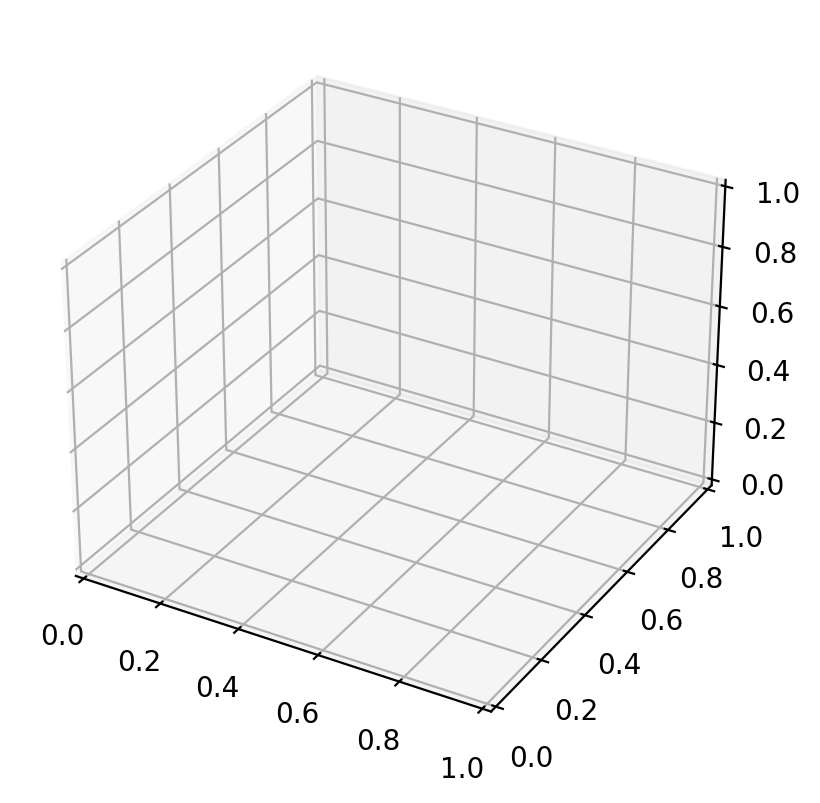

In [2]:
from base import MidiInstrument, MidiPercussion, PitchRange
from structures import MusicVoice, MusicUnit, MusicTime, MusicSection, MusicMatrix
from converters import unit_to_stream, midifile_to_score, score_to_matrix
from music21 import clef, percussion, instrument
from analysis import score_analyze

# Load
score1 = midifile_to_score('midipercussionmidi.mid')
score2 = midifile_to_score('r_son.mid')
score1.parts[0].insert(0, clef.PercussionClef())
score2.parts[0].insert(0, clef.PercussionClef())
score_analyze(score1)
score_analyze(score2)

matrix = score_to_matrix (score1)
print(matrix)

matrix = MusicMatrix(1,2)
# Meter 4/4, 8 timesteps, 0,5 beat per timestep
time = MusicTime(8, 4, 4, 100)
section = MusicSection(0, 'Percussion Section', time, matrix )
voices = [MusicVoice(0, 'Percussion voice', PitchRange(), MidiInstrument.PERCUSSION)]

instrument = instrument.Woodblock()
midi_inst = MidiInstrument.PERCUSSION

unit_bass = MusicUnit (0, "Bass",
    # Onset lines
    # bass drum on beats 1 & 3), snare on 2 & 4,
    [MidiPercussion.BASS_DRUM, MidiPercussion.ACOUSTIC_SNARE, MidiPercussion.BASS_DRUM, MidiPercussion.ACOUSTIC_SNARE],
    [2, 2, 2, 2],
    [1, 1, 1, 1],
    [110, 110, 110, 110, 110, 110, 110, 110])

unit_hi_hat = MusicUnit (1, "Hi-Hat",
    # hh on every eighth
    [MidiPercussion.CLOSED_HI_HAT, MidiPercussion.CLOSED_HI_HAT, MidiPercussion.CLOSED_HI_HAT, MidiPercussion.CLOSED_HI_HAT,
                     MidiPercussion.CLOSED_HI_HAT, MidiPercussion.CLOSED_HI_HAT, MidiPercussion.CLOSED_HI_HAT, MidiPercussion.CLOSED_HI_HAT],
    [1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1],
    [70, 70, 70, 70, 70, 70, 70, 70])

matrix.set_unit(0,0, unit_bass)
matrix.set_unit(0,1, unit_hi_hat)

p_chord = percussion.PercussionChord()
print(p_chord)

unit_to_stream(unit_bass)
unit_to_stream(unit_hi_hat)

